# What is Secondary Structure?

Proteins are made of amino acids linked into a chain (the primary structure).

That chain folds locally into recurring patterns called secondary structure, mainly caused by hydrogen bonding along the protein backbone.

There are three major classes:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


import requests
import os
from Bio.PDB import PDBList
from Bio.PDB import PDBParser
from Bio.SeqUtils import seq1
from Bio.PDB import DSSP

In [2]:
from pathlib import Path
current_dir = Path.cwd()
data_dir = f'{current_dir.parent.parent}/data/pdb'

In [3]:
os.makedirs(data_dir, exist_ok=True) 

In [4]:
# Download pdb file
pdb_id = "1crn"  # Small protein: Crambin
pdbl = PDBList()
pdb_file = pdbl.retrieve_pdb_file(pdb_id, pdir=data_dir, file_format="pdb")

Structure exists: '/home/sud/dev/protein-ai/data/pdb/pdb1crn.ent' 


**Extract Sequence**

- The amino-acid sequence of each chain (in 1-letter format)
- The 3D coordinates of each Cα atom (alpha carbon) for that chain

Bio.PDB organizes structures like-
```
Structure ->  Model -> Chain ->  Residue -> Atom
```

In [5]:
def extract_sequence_and_coordinates(pdb_file):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure('protein', pdb_file)
    
    sequences = []
    coordinates = []
    
    for model in structure:
        for chain in model:
            chain_sequence = []
            chain_coords = []
            
            for residue in chain: 
                if residue.get_id()[0] == ' ':  # Keep only standard amino acids
                    aa_name = residue.get_resname()
                    aa_one_letter = seq1(aa_name)
                    chain_sequence.append(aa_one_letter)  
                    if 'CA' in residue:
                        ca_atom = residue['CA']
                        chain_coords.append(ca_atom.get_coord())
            
            sequences.append(''.join(chain_sequence))
            coordinates.append(chain_coords)
    
    return sequences, coordinates

# Extract data
sequences, coordinates = extract_sequence_and_coordinates(pdb_file)
print(f"Sequence: {sequences[0]}")
print(f"Sequence length: {len(sequences[0])}")
print(f"Number of CA atoms: {len(coordinates[0])}")

Sequence: TTCCPSIVARSNFNVCRLPGTPEAICATYTGCIIIPGATCPGDYAN
Sequence length: 46
Number of CA atoms: 46


## Run DSSP to Get Secondary Structure Labels

Biopython's DSSP does not work out of the box. 
mkdssp (preferred)

Install dssp

```

conda install -c salilab dssp

```


#  Issue with `.ent` file


The downloaded pdb file had `.ent` extension. This caused problem with `DSSP` in following line.

`dssp = DSSP(model, pdb_file)`

having `.pdb` extension for the same `.ent` file works though.

Therefore, copy the file with extension `.pdb`

In [6]:
p = Path(pdb_file)
pdb_file_pdb = p.with_suffix(".pdb")
pdb_file_pdb.write_bytes(p.read_bytes())

49491

In [7]:
def get_secondary_structure(pdb_file):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure('protein', pdb_file_pdb)
    model = structure[0]  # Use first model
    
    # Run DSSP
    dssp = DSSP(model, pdb_file)
    
    # Extract secondary structure labels
    ss_labels = []
    dssp_data = []
    
    for key in dssp.keys():
        aa = dssp[key][1]  # Amino acid
        ss = dssp[key][2]  # Secondary structure
        ss_simple = simplify_ss_label(ss)  # Convert to H, E, C
        ss_labels.append(ss_simple)
        dssp_data.append({
            'residue_number': key[1][1],
            'amino_acid': aa,
            'secondary_structure': ss,
            'simple_ss': ss_simple,
            'accessibility': dssp[key][3]
        })
    
    return ss_labels, pd.DataFrame(dssp_data)

def simplify_ss_label(ss_code): 
    # H: Helix (H, G, I)
    if ss_code in ['H', 'G', 'I']:
        return 'H'
    # E: Sheet (E, B)
    elif ss_code in ['E', 'B']:
        return 'E'
    # C: Coil (everything else)
    else:
        return 'C'

# Get secondary structure
ss_labels, dssp_df = get_secondary_structure(pdb_file_pdb)
print(f"Secondary structure labels: {''.join(ss_labels)}")
print(f"SS distribution: {pd.Series(ss_labels).value_counts()}")

Secondary structure labels: CEECCCHHHHHHHHHHHCCCCCHHHHHHHHCCEECCCCCCCHHHCC
SS distribution: H    22
C    20
E     4
Name: count, dtype: int64


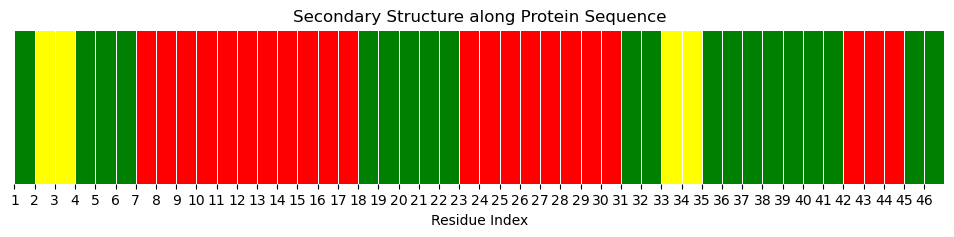

In [8]:
ss_map = {'C': 0, 'E': 1, 'H': 2} # map for plotting
ss_numeric = [ss_map[ss] for ss in ss_labels]

df = pd.DataFrame({'Residue': range(1, len(ss_labels)+1), 'SS': ss_numeric})
# Set up colors
colors = ['green', 'yellow', 'red']  # C=green, E=yellow, H=red
plt.figure(figsize=(12, 2))
sns.heatmap([df['SS']], cmap=colors, cbar=False, linewidths=0.5)

plt.yticks([])  # hide y-axis
plt.xticks(range(len(ss_labels)), df['Residue'])
plt.xlabel('Residue Index')
plt.title('Secondary Structure along Protein Sequence')
plt.show()